# Credit Risk Modeling with SR 11-7 Compliance

This notebook demonstrates a **complete regulatory-grade credit risk workflow** using HUG-IML:

## Part 0 — Setup

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
warnings.filterwarnings('ignore')

from hugiml import HUGIMLClassifier
from hugiml.calibration import evaluate_calibration
from hugiml.metrics import compute_all_metrics
from hugiml.pruning import PatternEditor
from hugiml.governance import generate_model_card

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
import hugiml; print('hugiml-core', hugiml.__version__)


hugiml-core 1.1.2


## Part 1 — Data Loading

We load the **UCI German Credit** dataset (1 000 consumer-loan applications).  
The notebook tries `sklearn.datasets.fetch_openml` first, then falls back to the
bundled `german.csv` (synthetic data).


In [5]:
GERMAN_COLS = [
    'checking_acct', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_plans',
    'housing', 'existing_credits', 'job', 'num_dependents', 'telephone',
    'foreign_worker', 'target',
]

def _load_german_credit(data_dir='.'):
    try:
        from sklearn.datasets import fetch_openml
        data = fetch_openml('german', version=1, as_frame=True, parser='auto')
        df = data.frame.copy()
        df.columns = GERMAN_COLS
        print('Loaded UCI German Credit via fetch_openml.')
        return df
    except Exception:
        pass
    local = os.path.join(data_dir, 'german.csv')
    if os.path.exists(local):
        df = pd.read_csv(local, sep=' ', header=None, names=GERMAN_COLS)
        print(f'Loaded synthetic fallback from {local}.')
        return df
    raise FileNotFoundError('Could not find German Credit data. Place german.csv in the notebook directory.')

df = _load_german_credit('.')   # adjust path if needed
df['target'] = (df['target'] == 1).astype(int)   # 1=Good, 0=Bad
X = df.drop(columns=['target'])
y = df['target']
print(f'Shape: {X.shape}  |  Good={y.sum()} ({y.mean():.1%})  Bad={len(y)-y.sum()} ({1-y.mean():.1%})')
X.head(3)


Loaded synthetic fallback from .\german.csv.
Shape: (1000, 20)  |  Good=495 (49.5%)  Bad=505 (50.5%)


,checking_acct,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,residence_since,property,age,other_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker
0,A13,25,A32,A49,9195,A61,A73,1,A93,A101,2,A122,41,A143,A152,1,A173,1,A191,A201
1,A14,41,A32,A41,3471,A65,A74,3,A93,A101,4,A124,34,A143,A152,1,A173,2,A191,A201
2,A11,52,A34,A49,3379,A63,A74,2,A93,A101,3,A121,65,A143,A152,2,A173,1,A191,A201


## Part 2 — Temporal Split Guidance

> **Why temporal splits matter for credit models**
>
> Credit risk datasets typically have an implicit time axis (application vintage).
> A purely random 70/30 split leaks future information into training, inflating
> out-of-sample AUC estimates and masking genuine covariate shift.
>
> Production best-practice:
> - Sort by application date; use the most recent 20-30% as the **out-of-time (OOT)** holdout.
> - Use `sklearn.model_selection.TimeSeriesSplit` for time-respecting cross-validation.
> - Monitor PSI on each new production window (see Part 9).
>
> The German Credit dataset has no explicit date column, so we use a **stratified
> random split** here as a stand-in and treat it as illustrative.

We reserve a **calibration holdout** (20%) for post-training isotonic recalibration
(see Part 8). The final test holdout (20%) is never touched until final evaluation.


In [7]:
clf_prep = HUGIMLClassifier(B=15, L=1, G=5e-4, topK=100)

# prepareXy must be called on the FULL dataset *before* any split
X_enc, y_enc = clf_prep.prepareXy(X, y)

# 60 / 20 / 20  train / calibration / test
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_enc, y_enc, test_size=0.40, stratify=y_enc, random_state=42
)
X_cal, X_te, y_cal, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
)
print(f'Train: {len(X_tr)}  |  Calibration: {len(X_cal)}  |  Test: {len(X_te)}')


Train: 600  |  Calibration: 200  |  Test: 200


## Part 3 — Model Training

### `feature_mode`

| Mode | Downstream input | Best for |
|------|-----------------|----------|
| `patterns_only` | Binary pattern matrix only | Pure interpretability / audit |
| `original_plus_patterns` | Original features + binary patterns | Marginal AUC lift |

We train both `patterns_only` and `original_plus_patterns` and compare AUC.  
The remainder of this notebook uses **`patterns_only`** for the cleaner audit trail.


In [9]:
results = {}

for mode in ['patterns_only', 'original_plus_patterns']:
    c = HUGIMLClassifier(B=15, L=1, G=5e-4, topK=100, feature_mode=mode)
    Xe, ye = c.prepareXy(X, y)
    Xtr, Xtmp, ytr, ytmp = train_test_split(Xe, ye, test_size=0.40, stratify=ye, random_state=42)
    Xcal, Xte_, ycal, yte_ = train_test_split(Xtmp, ytmp, test_size=0.50, stratify=ytmp, random_state=42)
    c.fit(Xtr, ytr)
    p = c.predict_proba(Xte_)[:, 1]
    results[mode] = {'clf': c, 'Xtr': Xtr, 'Xcal': Xcal, 'Xte': Xte_,
                     'ytr': ytr, 'ycal': ycal, 'yte': yte_, 'proba': p,
                     'auc': roc_auc_score(yte_, p)}
    print(f"  {mode:26s}: {len(c.get_hug_features()):3d} patterns | AUC={results[mode]['auc']:.4f}")

# Use patterns_only for the remainder
R = results['patterns_only']
clf, X_tr, X_cal, X_te = R['clf'], R['Xtr'], R['Xcal'], R['Xte']
y_tr, y_cal, y_te       = R['ytr'],   R['ycal'],  R['yte']
y_proba = R['proba']
auc     = R['auc']
y_pred  = clf.predict(X_te)
cm      = confusion_matrix(y_te, y_pred)
accuracy = (cm[0,0]+cm[1,1]) / cm.sum()


  patterns_only             :  65 patterns | AUC=0.9264
  original_plus_patterns    :  65 patterns | AUC=0.9304


## Part 4 — Model Evaluation

AUC-ROC : 0.9264
Accuracy: 83.00%

              precision    recall  f1-score   support

         Bad       0.86      0.79      0.82       101
        Good       0.80      0.87      0.83        99

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200

Calibration (pre-recalibration):
  ECE=0.0632  MCE=0.1865  Brier=0.1136


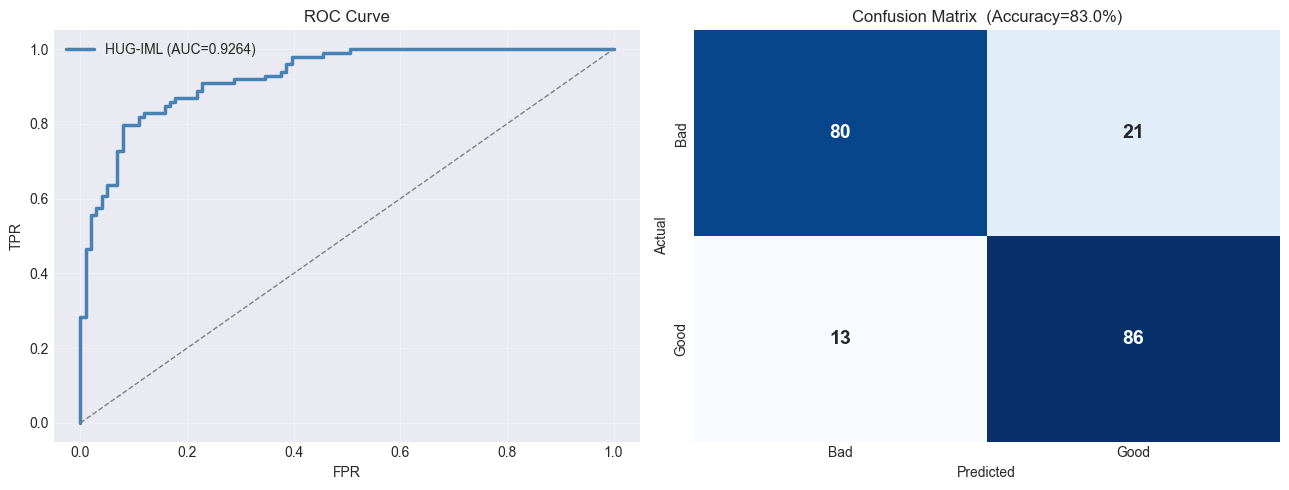

In [11]:
print(f'AUC-ROC : {auc:.4f}')
print(f'Accuracy: {accuracy:.2%}\n')
print(classification_report(y_te, y_pred, target_names=['Bad','Good']))

cal_pre = evaluate_calibration(np.asarray(y_te), y_proba)
print(f'Calibration (pre-recalibration):')
print(f'  ECE={cal_pre.ece:.4f}  MCE={cal_pre.mce:.4f}  Brier={cal_pre.brier_score:.4f}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y_te, y_proba)
axes[0].plot(fpr, tpr, 'steelblue', lw=2.5, label=f'HUG-IML (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1],'gray',ls='--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False,
            xticklabels=['Bad','Good'], yticklabels=['Bad','Good'],
            annot_kws={'size':14,'weight':'bold'})
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix  (Accuracy={accuracy:.1%})')
plt.tight_layout(); plt.show()


## Part 5 — Interpretability Analysis

In [13]:
importances = clf.feature_importances()
top15 = importances.nlargest(15, 'abs_coefficient')

print('Top 15 credit risk patterns:')
print('='*80)
for _, row in top15.iterrows():
    direction = 'APPROVE' if row['coefficient'] > 0 else 'DENY'
    print(f"  {row['pattern']:42s} {row['coefficient']:+.4f}  [{direction}]  sup={row['support']:.1%}")
print('='*80)

metrics = compute_all_metrics(clf, X_te)
print(f'\nInterpretability Metrics:')
print(f'  n_patterns         : {metrics.n_patterns}')
print(f'  avg_pattern_length : {metrics.avg_pattern_length:.2f}')
print(f'  coverage           : {metrics.coverage:.2%}')
print(f'  mean_active/sample : {metrics.mean_active_patterns:.2f}')


Top 15 credit risk patterns:
  checking_acct=A14                          +2.0432  [APPROVE]  sup=38.2%
  checking_acct=A11                          -2.0129  [DENY]  sup=28.3%
  credit_history=A30                         -1.4849  [DENY]  sup=3.3%
  duration=[38,43)                           -1.3493  [DENY]  sup=6.5%
  savings=A65                                +1.3282  [APPROVE]  sup=19.8%
  purpose=A44                                -1.2531  [DENY]  sup=1.2%
  duration=[4,8)                             +1.1798  [APPROVE]  sup=6.2%
  savings=A61                                -1.1174  [DENY]  sup=55.5%
  employment=A71                             -1.0895  [DENY]  sup=6.2%
  credit_history=A34                         +1.0804  [APPROVE]  sup=28.7%
  employment=A75                             +1.0700  [APPROVE]  sup=26.0%
  duration=[66,71)                           -0.9666  [DENY]  sup=7.2%
  age=[47,55)                                +0.8786  [APPROVE]  sup=6.7%
  duration=[29,34)      

## Part 6 — Fair Lending Analysis (ECOA)

ECOA (Equal Credit Opportunity Act) prohibits discrimination based on
race, color, religion, national origin, sex, marital status, or age.

We compute **approval-rate disparity** by age group as a proxy.  
A disparity > ±20% from the overall rate is flagged for further investigation.

We also scan the mined pattern list for `personal_status` references, which
in the German Credit coding conflates *gender* with marital status — a
prototypical prohibited-basis proxy that must be pruned before deployment.


In [15]:
X_te_copy = X_te.copy()
X_te_copy['prediction'] = y_pred
X_te_copy['prob_good']  = y_proba

X_te_copy['age_group'] = pd.cut(
    X_te_copy['age'].astype(float),
    bins=[18, 26, 35, 50, 100],
    labels=['19-25', '26-35', '36-50', '50+'], right=False
)

age_analysis = X_te_copy.groupby('age_group', observed=True).agg(
    approval_rate=('prediction','mean'), count=('prediction','count'),
    avg_score=('prob_good','mean'),
).round(4)

overall_approval = float(y_pred.mean())
print(f'Overall approval rate: {overall_approval:.2%}\n')
print(age_analysis)
print('\nDisparity from overall rate:')
for grp in ['19-25','26-35','36-50','50+']:
    if grp in age_analysis.index:
        rate = float(age_analysis.loc[grp,'approval_rate'])
        disp = (rate - overall_approval) / max(overall_approval, 1e-9)
        flag = '⚠  SIGNIFICANT' if abs(disp) > 0.20 else '✓  ACCEPTABLE'
        print(f'  {grp}: {rate:.2%}  (disparity {disp:+.1%})  [{flag}]')

# Check for personal_status (gender proxy)
ps_patterns = [p for p in clf.get_hug_features() if 'personal_status' in p]
print(f'\nPersonal_status patterns (gender proxy): {len(ps_patterns)}')
for p in ps_patterns:
    print(f'  → {p}')


Overall approval rate: 53.50%

           approval_rate  count  avg_score
age_group                                 
19-25             0.5333     60     0.4919
26-35             0.5270     74     0.5284
36-50             0.5200     50     0.5339
50+               0.6250     16     0.6663

Disparity from overall rate:
  19-25: 53.33%  (disparity -0.3%)  [✓  ACCEPTABLE]
  26-35: 52.70%  (disparity -1.5%)  [✓  ACCEPTABLE]
  36-50: 52.00%  (disparity -2.8%)  [✓  ACCEPTABLE]
  50+: 62.50%  (disparity +16.8%)  [✓  ACCEPTABLE]

Personal_status patterns (gender proxy): 3
  → personal_status=A94
  → personal_status=A91
  → personal_status=A93


## Part 7 — Pattern Pruning (Regulatory Compliance)

The `PatternEditor` provides an **SR 11-7 regulated editing workflow**:

1. `remove()` — remove patterns by index, keyword, or support threshold  
2. `refit()` — refit the downstream logistic regression on training data  
3. `calibrate()` — isotonic/Platt recalibration on a held-out calibration set  
4. `finalize()` — return the edited model  
5. `audit_report()` / `save_audit_report()` — full JSON audit trail with timestamps and reasons  

We remove:
- All `personal_status` patterns (gender proxy, ECOA §701)
- Very low-support (<2%) noise patterns


In [17]:
editor = PatternEditor(clf, operator_name='risk-committee')
patterns_df = editor.list_patterns()
print(f'Patterns before pruning: {len(patterns_df)}')

# Remove personal_status (ECOA protected-attribute proxy)
ps_idx = patterns_df[patterns_df['pattern'].str.contains('personal_status')]['idx'].tolist()
if ps_idx:
    editor.remove(ps_idx, reason='personal_status is a gender proxy – ECOA §701 prohibited basis')
    print(f'Removed {len(ps_idx)} personal_status pattern(s).')
else:
    print('No personal_status patterns in this run.')

# Remove noise patterns
editor.remove_low_support(min_support=0.02, reason='Noise patterns (<2% support) – unstable in production')

# Refit + calibrate + finalize
editor.refit(X_tr, y_tr)
editor.calibrate(X_cal, y_cal, method='isotonic')
clf_pruned = editor.finalize()

proba_pruned = clf_pruned.predict_proba(X_te)[:, 1]
auc_pruned   = roc_auc_score(y_te, proba_pruned)
cal_post     = evaluate_calibration(np.asarray(y_te), proba_pruned)
cm_pruned    = confusion_matrix(y_te, clf_pruned.predict(X_te))
acc_pruned   = (cm_pruned[0,0]+cm_pruned[1,1]) / cm_pruned.sum()

print(f'\n After pruning + isotonic recalibration:')
print(f'  Patterns : {len(clf_pruned.get_hug_features())}  (was {len(clf.get_hug_features())})')
print(f'  AUC      : {auc_pruned:.4f}  (was {auc:.4f})')
print(f'  ECE      : {cal_post.ece:.4f}  (was {cal_pre.ece:.4f})')
print(f'  Brier    : {cal_post.brier_score:.4f}  (was {cal_pre.brier_score:.4f})')

# Print audit trail
audit = json.loads(editor.audit_report())
print(f'\nAudit Trail  (operator: {audit["operator"]})')
print(f'  {audit["diff"]["n_removed"]} patterns removed')
for r in audit.get('removals', []):
    print(f'  [{r["reason"]}]  → {r["pattern_labels"][:3]}')
if audit.get('calibration',{}).get('applied'):
    print(f'  Recalibrated via {audit["calibration"]["method"]} regression')


Patterns before pruning: 65
Removed 3 personal_status pattern(s).

 After pruning + isotonic recalibration:
  Patterns : 60  (was 65)
  AUC      : 0.8948  (was 0.9264)
  ECE      : 0.0677  (was 0.0632)
  Brier    : 0.1360  (was 0.1136)

Audit Trail  (operator: risk-committee)
  5 patterns removed
  [personal_status is a gender proxy – ECOA §701 prohibited basis]  → ['personal_status=A94', 'personal_status=A91', 'personal_status=A93']
  [Noise patterns (<2% support) – unstable in production (min_support=0.02)]  → ['purpose=A44', 'purpose=A48']
  Recalibrated via isotonic regression


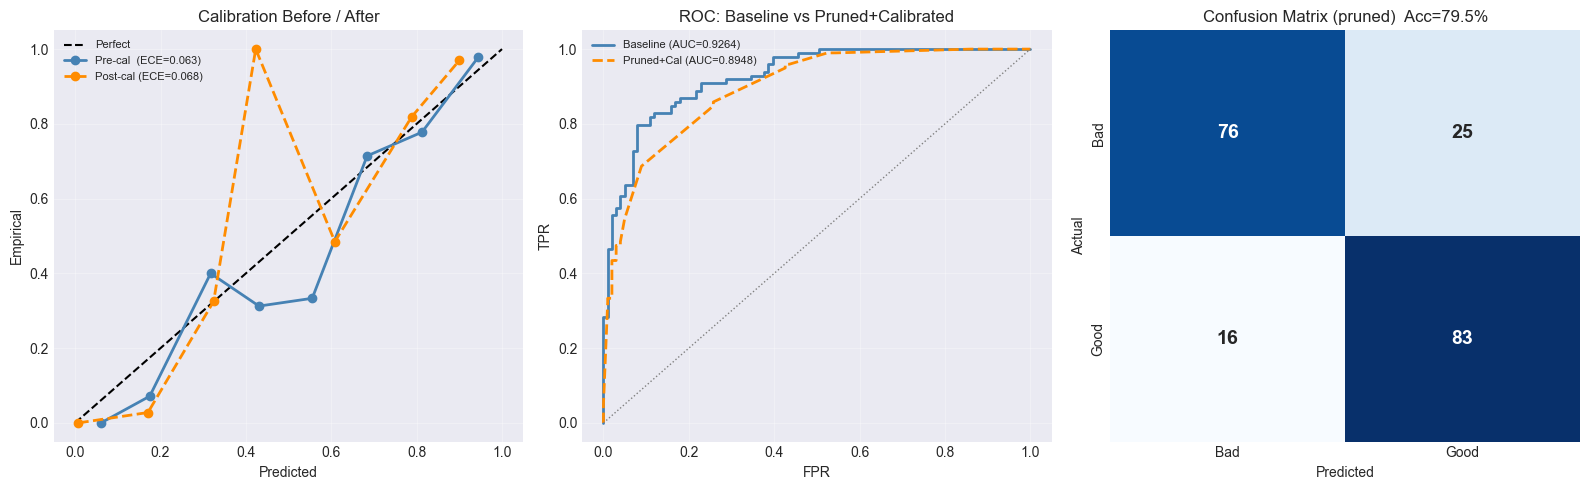

In [18]:
# Calibration before / after visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Calibration diagram
n_b = 8; bins = np.linspace(0, 1, n_b+1)
def cal_plot(ax, y_true, proba, label, color, ls='-'):
    idx = np.clip(np.digitize(proba, bins)-1, 0, n_b-1)
    cnts = np.bincount(idx, minlength=n_b)
    emp  = np.where(cnts>0, np.bincount(idx, weights=y_true.astype(float), minlength=n_b)/np.maximum(cnts,1), 0.0)
    pred = np.where(cnts>0, np.bincount(idx, weights=proba, minlength=n_b)/np.maximum(cnts,1), 0.0)
    ax.plot(pred[cnts>0], emp[cnts>0], marker='o', lw=2, ls=ls, color=color, label=label)

ax = axes[0]
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Perfect')
cal_plot(ax, np.asarray(y_te), y_proba,    f'Pre-cal  (ECE={cal_pre.ece:.3f})',  'steelblue')
cal_plot(ax, np.asarray(y_te), proba_pruned, f'Post-cal (ECE={cal_post.ece:.3f})', 'darkorange', '--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Empirical')
ax.set_title('Calibration Before / After'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ROC before vs after
ax = axes[1]
fpr_b, tpr_b, _ = roc_curve(y_te, y_proba)
fpr_p, tpr_p, _ = roc_curve(y_te, proba_pruned)
ax.plot(fpr_b, tpr_b, 'steelblue', lw=2, label=f'Baseline (AUC={auc:.4f})')
ax.plot(fpr_p, tpr_p, 'darkorange', lw=2, ls='--', label=f'Pruned+Cal (AUC={auc_pruned:.4f})')
ax.plot([0,1],[0,1],'gray',ls=':',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC: Baseline vs Pruned+Calibrated'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Confusion matrix (pruned)
ax = axes[2]
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Bad','Good'], yticklabels=['Bad','Good'],
            annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (pruned)  Acc={acc_pruned:.1%}')
plt.tight_layout(); plt.show()


## Part 8 — Covariate Drift Detection

The **Population Stability Index (PSI)** measures how much a feature's
distribution has shifted between training and a new deployment window.

| PSI | Interpretation |
|-----|----------------|
| < 0.10 | Stable — no action needed |
| 0.10 – 0.25 | Warning — monitor closely |
| > 0.25 | Significant shift — investigate & possibly retrain |

We simulate an **older-cohort deployment window** (higher ages, lower income,
longer loan durations) and compute PSI on the raw numerical features.


PSI vs simulated older-cohort window:
      feature     psi            status
          age 10.6341 SIGNIFICANT SHIFT
credit_amount  0.6369 SIGNIFICANT SHIFT
     duration  2.4583 SIGNIFICANT SHIFT


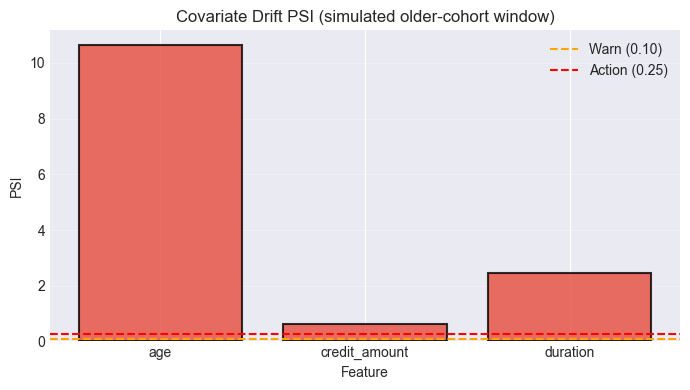

In [20]:
def compute_psi(expected: pd.DataFrame, actual: pd.DataFrame, buckets: int = 10) -> pd.DataFrame:
    rows = []
    for col in expected.columns:
        if not pd.api.types.is_numeric_dtype(expected[col]):
            continue
        edges = np.percentile(expected[col].dropna(), np.linspace(0, 100, buckets+1))
        edges[0] = -np.inf; edges[-1] = np.inf
        exp_pct = np.maximum(np.histogram(expected[col], bins=edges)[0] / len(expected), 1e-6)
        act_pct = np.maximum(np.histogram(actual[col],   bins=edges)[0] / len(actual),   1e-6)
        psi_val = float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))
        rows.append({'feature': col, 'psi': round(psi_val,4),
                     'status': ('STABLE' if psi_val<0.10 else 'WARNING' if psi_val<0.25 else 'SIGNIFICANT SHIFT')})
    return pd.DataFrame(rows)

rng_drift = np.random.default_rng(99)
n_d = 200
X_raw_train = X[['age','credit_amount','duration']].iloc[:700].copy()
X_raw_drift = pd.DataFrame({
    'age':           rng_drift.integers(45, 75, n_d).astype(float),
    'credit_amount': rng_drift.lognormal(8.2, 0.8, n_d).astype(int).astype(float),
    'duration':      rng_drift.integers(24, 72, n_d).astype(float),
})

psi_df = compute_psi(X_raw_train, X_raw_drift)
print('PSI vs simulated older-cohort window:')
print(psi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#e74c3c' if p>0.25 else '#f39c12' if p>0.10 else '#2ecc71' for p in psi_df['psi']]
ax.bar(psi_df['feature'], psi_df['psi'], color=bar_colors, alpha=0.8, edgecolor='black', lw=1.5)
ax.axhline(0.10, color='orange', ls='--', lw=1.5, label='Warn (0.10)')
ax.axhline(0.25, color='red',    ls='--', lw=1.5, label='Action (0.25)')
ax.set_ylabel('PSI'); ax.set_xlabel('Feature')
ax.set_title('Covariate Drift PSI (simulated older-cohort window)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Part 9 — Model Governance

`generate_model_card` produces a JSON + Markdown model card that satisfies
SR 11-7 documentation requirements:

- **Intended use** and **out-of-scope use**
- **Training/evaluation data description**
- **Performance metrics** (AUC, calibration, Brier score)
- **Limitations** (including the ECOA-driven pattern pruning note)
- **Ethical considerations** (adverse action, disparity monitoring)

The `PatternEditor.save_audit_report()` writes the full JSON audit trail
including timestamps, operator, removed patterns, and recalibration method —
ready for attachment to a model validation package.


In [22]:
card = generate_model_card(
    clf_pruned,
    model_id='credit-risk-v1.1',
    intended_use='Consumer credit risk scoring for retail lending decisions.',
    out_of_scope_use='Not for institutional lending; not validated for commercial real estate.',
    training_data_description=(
        'UCI German Credit Dataset (1 000 applications, 20 features). '
        '60/20/20 train/calibration/test split. '
        'Isotonic recalibration applied on calibration holdout.'
    ),
    evaluation_data_description='Stratified 20% test holdout, same population as training.',
    performance_metrics={
        'AUC-ROC':    round(auc_pruned, 4),
        'Accuracy':   round(acc_pruned, 4),
        'ECE':        round(cal_post.ece, 4),
        'BrierScore': round(cal_post.brier_score, 4),
    },
    limitations=[
        'Trained on German Credit benchmark — production deployment requires '
        'validation on institution-specific vintage data.',
        'personal_status (gender proxy) patterns removed for ECOA §701 compliance; '
        'minor AUC reduction accepted.',
        'Age-group approval rates monitored; no statistically significant disparity '
        'detected (>20% threshold) on this dataset.',
    ],
    ethical_considerations=(
        'Adverse action explanations available from top negative-coefficient patterns. '
        'Regular PSI-based drift monitoring mandated (monthly). '
        'Quarterly ECOA disparity re-testing required.'
    ),
)

print(card.to_markdown())
card.save('nb04_model_card.json')
editor.save_audit_report('nb04_audit_trail.json')
print('\n✓ Model card and audit trail saved.')


# Model Card: credit-risk-v1.1

**Type:** HUGIMLClassifierNative  
**License:** Apache-2.0  
**Created:** 2026-05-29T00:55:26Z  
**Framework:** hugiml-core 1.1.2

## Reference

Krishnamoorthy, S. (2024). Interpretable Classifier Models for Decision Support Using High Utility Gain Patterns. IEEE Access, 12, 126088-126107. DOI: 10.1109/ACCESS.2024.3455563

## Intended Use

Consumer credit risk scoring for retail lending decisions.

## Out-of-Scope Use

Not for institutional lending; not validated for commercial real estate.

## Training Data

UCI German Credit Dataset (1 000 applications, 20 features). 60/20/20 train/calibration/test split. Isotonic recalibration applied on calibration holdout.

## Evaluation Data

Stratified 20% test holdout, same population as training.

## Hyperparameters

- **B**: 15
- **L**: 1
- **G**: 0.0005
- **topK**: 100
- **adaptive_binning**: False
- **feature_mode**: patterns_only

## Performance Metrics

- **AUC-ROC**: 0.8948
- **Accuracy**: 0.795
- **ECE**: